In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/luse_historical_prices.csv")

df.head()

,ticker,date,price,volume
0,AECI,2017-03-07,6.80,0
1,AECI,2017-03-09,7.98,849023
2,AECI,2017-03-10,7.98,0
3,AECI,2017-03-14,7.98,0
4,AECI,2017-03-15,7.98,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47200 entries, 0 to 47199
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ticker  47200 non-null  object 
 1   date    47200 non-null  object 
 2   price   47200 non-null  float64
 3   volume  47200 non-null  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 1.4+ MB


In [3]:
df["date"] = pd.to_datetime(df["date"])

df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["volume"] = pd.to_numeric(df["volume"], errors="coerce")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47200 entries, 0 to 47199
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ticker  47200 non-null  object        
 1   date    47200 non-null  datetime64[ns]
 2   price   47200 non-null  float64       
 3   volume  47200 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 1.4+ MB


In [4]:
df.isna().sum()

ticker    0
date      0
price     0
volume    0
dtype: int64

In [5]:
df = df.sort_values(["ticker", "date"])

df["daily_return"] = df.groupby("ticker")["price"].pct_change()

df.head()

,ticker,date,price,volume,daily_return
0,AECI,2017-03-07,6.80,0,NaN
1,AECI,2017-03-09,7.98,849023,0.173529
2,AECI,2017-03-10,7.98,0,0.000000
3,AECI,2017-03-14,7.98,0,0.000000
4,AECI,2017-03-15,7.98,0,0.000000


In [6]:
df.to_csv("../data/processed/luse_historical_prices_clean.csv", index=False)

In [7]:
latest_prices = df.groupby("ticker").last()["price"]
first_prices = df.groupby("ticker").first()["price"]

performance = ((latest_prices - first_prices) / first_prices) * 100

performance = performance.sort_values(ascending=False)

performance.head(10)

ticker
CECZ    3686.666667
ZSUG    2662.222222
AECI    1737.352941
ZNCO    1495.000000
CHIL    1335.268817
ZMFA     940.000000
BATZ     535.000000
SHOP     455.555556
ATEL     422.707692
ZCCM     275.000000
Name: price, dtype: float64

In [8]:
performance.tail(10)

ticker
PUMA    195.959596
CECA     50.000000
DCZM     40.990371
REIZ     28.571429
ZABR      9.677419
ZMRE     -5.862069
ZMBF    -20.000000
SCBL    -26.315789
MAFS    -43.962848
NATB    -78.000000
Name: price, dtype: float64

In [9]:
volatility = df.groupby("ticker")["daily_return"].std()

volatility = volatility.sort_values(ascending=False)

volatility.head(10)

ticker
REIZ    0.034750
CHIL    0.028598
SCBL    0.027244
AECI    0.027109
DCZM    0.024911
CECZ    0.024049
ZNCO    0.023114
ZMBF    0.020958
ZSUG    0.020662
CECA    0.020582
Name: daily_return, dtype: float64

In [10]:
volume_analysis = df.groupby("ticker")["volume"].sum()

volume_analysis = volume_analysis.sort_values(ascending=False)

volume_analysis.head(10)

ticker
CECZ    1900876414
CECA    1178945154
REIZ     552668217
ZNCO     228698931
CHIL     186743769
SCBL     112100302
ZMBF      77464080
ZABR      75982760
BATZ      42776505
PUMA      35879766
Name: volume, dtype: int64

In [11]:
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'matplotlib'

In [12]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


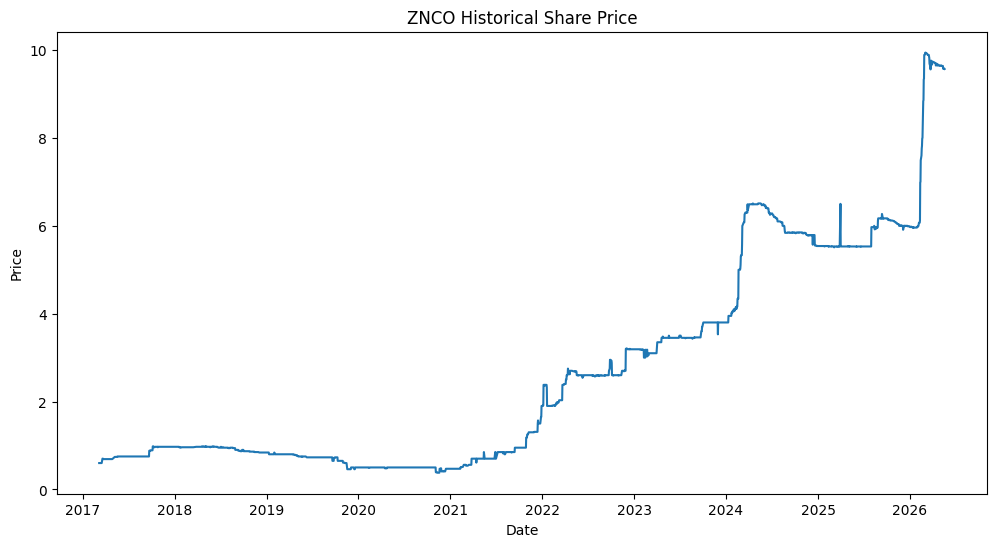

In [13]:
zanaco = df[df["ticker"] == "ZNCO"]

plt.figure(figsize=(12,6))
plt.plot(zanaco["date"], zanaco["price"])

plt.title("ZNCO Historical Share Price")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

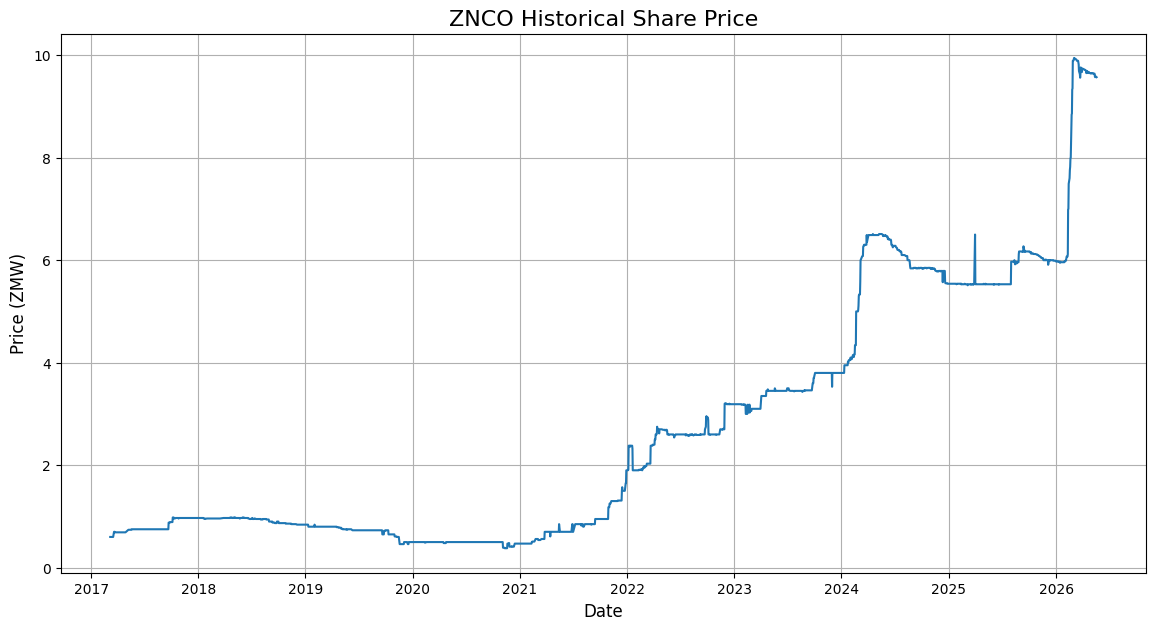

In [14]:
plt.figure(figsize=(14,7))

plt.plot(zanaco["date"], zanaco["price"])

plt.title("ZNCO Historical Share Price", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (ZMW)", fontsize=12)

plt.grid(True)

plt.show()

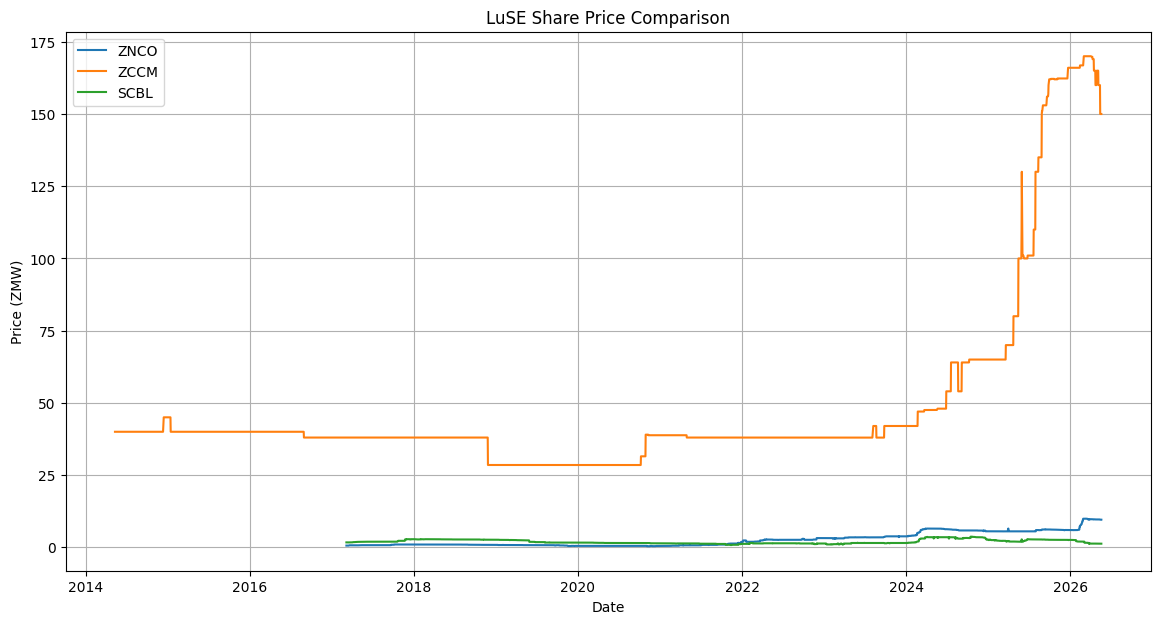

In [15]:
selected = df[df["ticker"].isin(["ZNCO", "ZCCM", "SCBL"])]

plt.figure(figsize=(14,7))

for ticker in ["ZNCO", "ZCCM", "SCBL"]:
    company = selected[selected["ticker"] == ticker]
    plt.plot(company["date"], company["price"], label=ticker)

plt.title("LuSE Share Price Comparison")
plt.xlabel("Date")
plt.ylabel("Price (ZMW)")

plt.legend()
plt.grid(True)

plt.show()

In [16]:
comparison = df[df["ticker"].isin(["ZNCO", "ZCCM", "SCBL"])].copy()

comparison["normalized_price"] = comparison.groupby("ticker")["price"].transform(
    lambda x: x / x.iloc[0]
)

comparison.head()

,ticker,date,price,volume,daily_return,normalized_price
24863,SCBL,2017-03-07,1.71,53,NaN,1.000000
24864,SCBL,2017-03-09,1.70,731880,-0.005848,0.994152
24865,SCBL,2017-03-10,1.70,0,0.000000,0.994152
24866,SCBL,2017-03-14,1.69,8933,-0.005882,0.988304
24867,SCBL,2017-03-15,1.69,120517,0.000000,0.988304


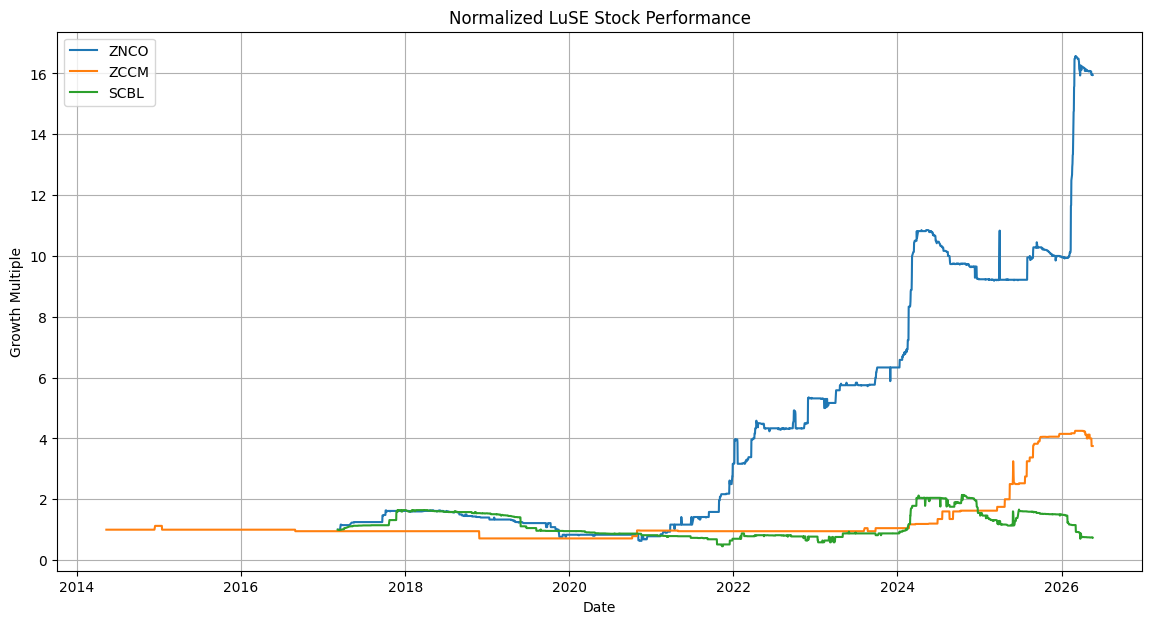

In [17]:
plt.figure(figsize=(14,7))

for ticker in ["ZNCO", "ZCCM", "SCBL"]:
    company = comparison[comparison["ticker"] == ticker]

    plt.plot(
        company["date"],
        company["normalized_price"],
        label=ticker
    )

plt.title("Normalized LuSE Stock Performance")
plt.xlabel("Date")
plt.ylabel("Growth Multiple")

plt.legend()
plt.grid(True)

plt.show()

In [18]:
volatility = df.groupby("ticker")["daily_return"].std() * 100

volatility = volatility.sort_values(ascending=False)

volatility.head(10)

ticker
REIZ    3.474973
CHIL    2.859824
SCBL    2.724427
AECI    2.710927
DCZM    2.491120
CECZ    2.404930
ZNCO    2.311445
ZMBF    2.095764
ZSUG    2.066226
CECA    2.058197
Name: daily_return, dtype: float64

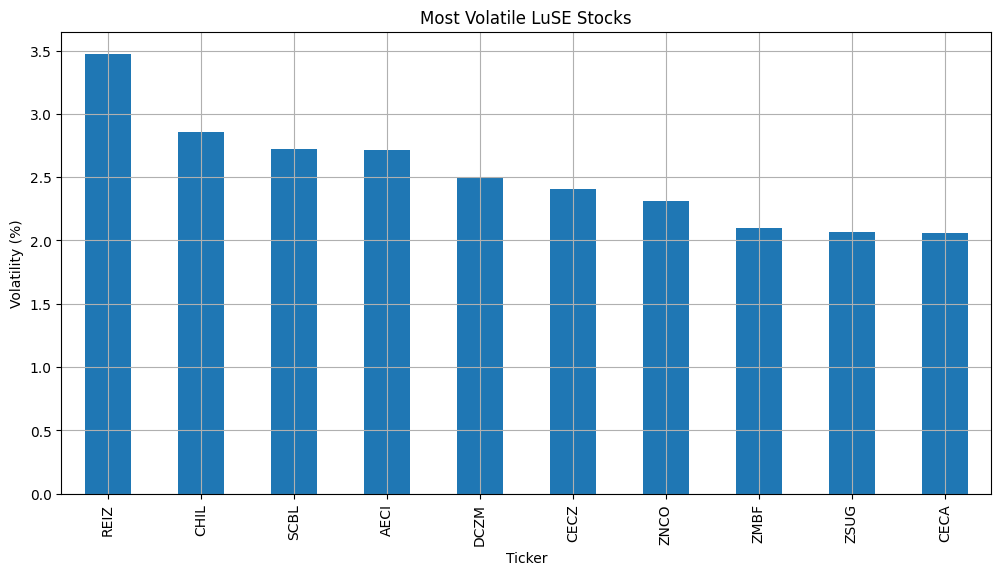

In [19]:
top_volatile = volatility.head(10)

plt.figure(figsize=(12,6))

top_volatile.plot(kind="bar")

plt.title("Most Volatile LuSE Stocks")
plt.xlabel("Ticker")
plt.ylabel("Volatility (%)")

plt.grid(True)

plt.show()

In [20]:
price_matrix = df.pivot_table(
    index="date",
    columns="ticker",
    values="price"
)

price_matrix.head()

ticker,AECI,ATEL,BATA,BATZ,CECA,CECZ,CHIL,DCZM,MAFS,NATB,...,SCBL,SHOP,ZABR,ZCCM,ZFCO,ZMBF,ZMFA,ZMRE,ZNCO,ZSUG
date,,,,,,,,,,,,,,,,,,,,,
2008-01-21,NaN,NaN,NaN,NaN,NaN,0.450,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-22,NaN,NaN,NaN,NaN,NaN,0.450,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-23,NaN,NaN,NaN,NaN,NaN,0.625,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-24,NaN,NaN,NaN,NaN,NaN,0.625,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-25,NaN,NaN,NaN,NaN,NaN,0.627,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
correlation_matrix = price_matrix.corr()

correlation_matrix.head()

ticker,AECI,ATEL,BATA,BATZ,CECA,CECZ,CHIL,DCZM,MAFS,NATB,...,SCBL,SHOP,ZABR,ZCCM,ZFCO,ZMBF,ZMFA,ZMRE,ZNCO,ZSUG
ticker,,,,,,,,,,,,,,,,,,,,,
AECI,1.000000,0.873243,0.778759,0.918943,0.719871,0.791799,0.935545,0.687860,-0.671835,-0.644433,...,0.057952,0.769112,-0.211822,0.927953,0.826134,0.049543,0.928409,0.035570,0.772536,0.901626
ATEL,0.873243,1.000000,0.860652,0.955301,0.607651,0.837800,0.863597,-0.370300,-0.580703,-0.427483,...,0.265531,0.891129,-0.156985,0.960372,0.875852,0.030814,0.901113,-0.129375,0.707001,0.830839
BATA,0.778759,0.860652,1.000000,0.825866,0.731722,0.916048,0.871820,-0.174772,-0.784805,-0.630813,...,0.342145,0.927045,-0.242105,0.888659,0.874526,-0.040426,0.723555,-0.054667,0.862956,0.898762
BATZ,0.918943,0.955301,0.825866,1.000000,0.642363,0.833409,0.875855,0.459591,-0.566338,-0.460980,...,0.221625,0.871086,-0.169965,0.977013,0.797874,0.008977,0.962780,-0.098289,0.675893,0.831745
CECA,0.719871,0.607651,0.731722,0.642363,1.000000,0.825380,0.734002,0.336208,-0.806840,-0.795530,...,0.307165,0.712975,-0.376225,0.710090,0.710991,0.356741,0.534947,-0.067838,0.846448,0.835570


In [22]:
import seaborn as sns

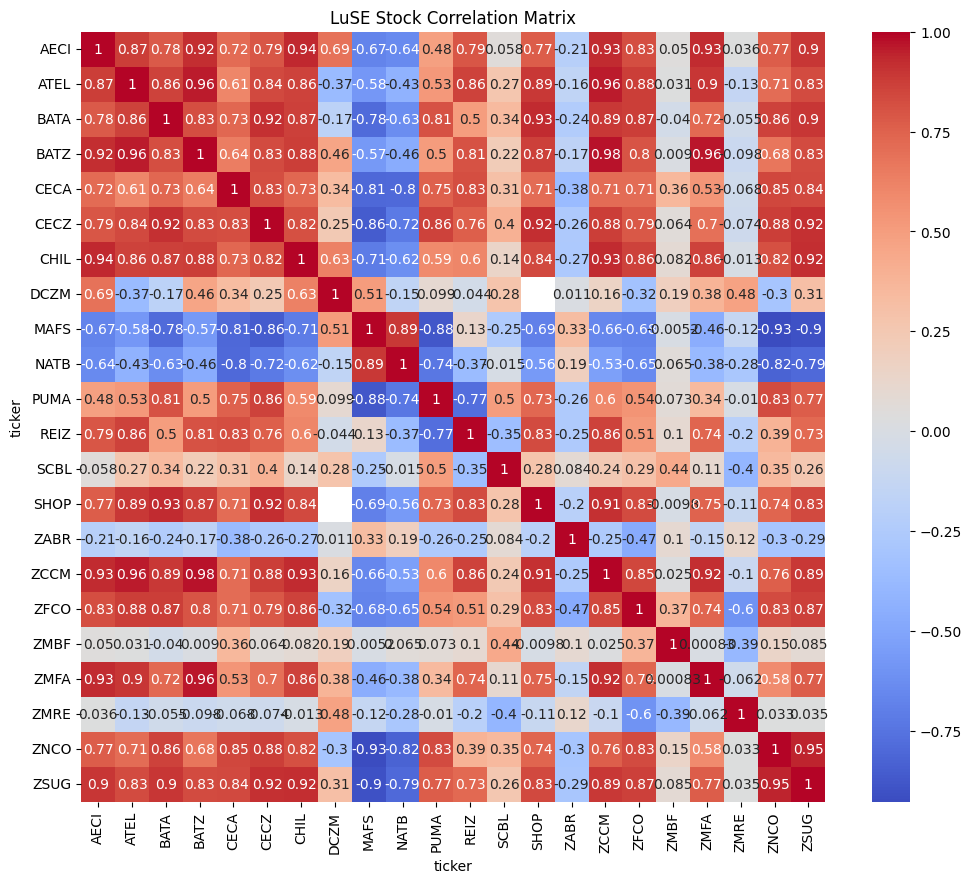

In [23]:
plt.figure(figsize=(12,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("LuSE Stock Correlation Matrix")

plt.show()

In [24]:
portfolio_stocks = ["ZNCO", "ZCCM", "SCBL"]

portfolio = df[df["ticker"].isin(portfolio_stocks)].copy()

portfolio.head()

,ticker,date,price,volume,daily_return
24863,SCBL,2017-03-07,1.71,53,NaN
24864,SCBL,2017-03-09,1.70,731880,-0.005848
24865,SCBL,2017-03-10,1.70,0,0.000000
24866,SCBL,2017-03-14,1.69,8933,-0.005882
24867,SCBL,2017-03-15,1.69,120517,0.000000


In [25]:
portfolio["normalized_price"] = portfolio.groupby("ticker")["price"].transform(
    lambda x: x / x.iloc[0]
)

portfolio.head()

,ticker,date,price,volume,daily_return,normalized_price
24863,SCBL,2017-03-07,1.71,53,NaN,1.000000
24864,SCBL,2017-03-09,1.70,731880,-0.005848,0.994152
24865,SCBL,2017-03-10,1.70,0,0.000000,0.994152
24866,SCBL,2017-03-14,1.69,8933,-0.005882,0.988304
24867,SCBL,2017-03-15,1.69,120517,0.000000,0.988304


In [26]:
portfolio_pivot = portfolio.pivot_table(
    index="date",
    columns="ticker",
    values="normalized_price"
)

portfolio_pivot.head()

ticker,SCBL,ZCCM,ZNCO
date,,,
2014-05-12,NaN,1.0,NaN
2014-05-13,NaN,1.0,NaN
2014-05-14,NaN,1.0,NaN
2014-05-15,NaN,1.0,NaN
2014-05-16,NaN,1.0,NaN


In [27]:
weights = [0.33, 0.33, 0.34]

In [28]:
portfolio_pivot["portfolio_value"] = (
    portfolio_pivot * weights
).sum(axis=1)

portfolio_pivot.head()

ticker,SCBL,ZCCM,ZNCO,portfolio_value
date,,,,
2014-05-12,NaN,1.0,NaN,0.33
2014-05-13,NaN,1.0,NaN,0.33
2014-05-14,NaN,1.0,NaN,0.33
2014-05-15,NaN,1.0,NaN,0.33
2014-05-16,NaN,1.0,NaN,0.33


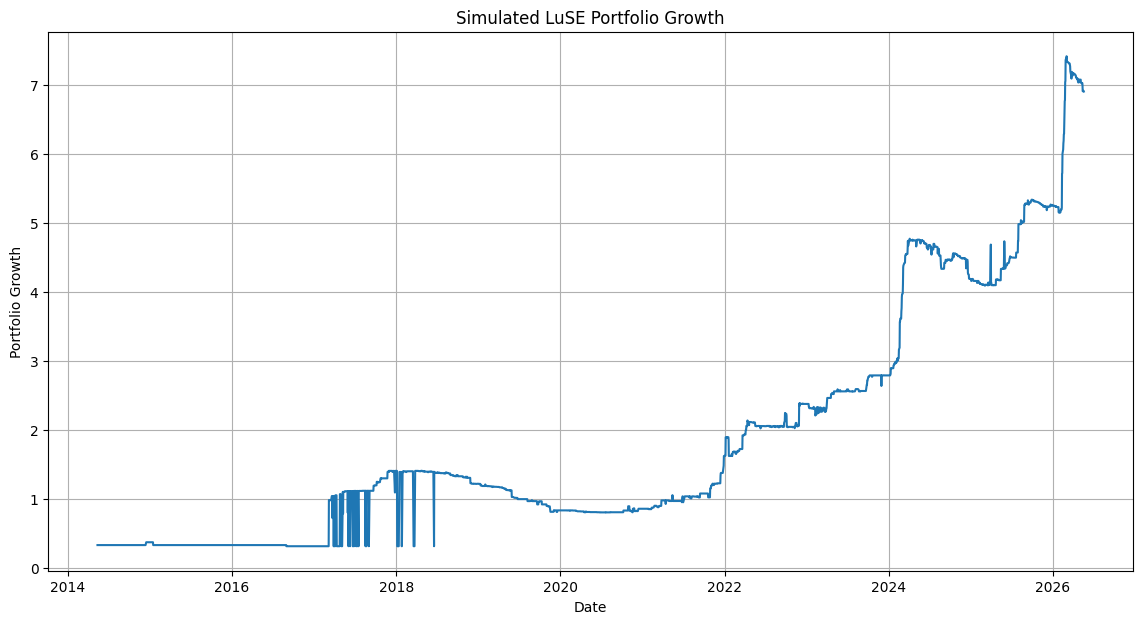

In [29]:
plt.figure(figsize=(14,7))

plt.plot(
    portfolio_pivot.index,
    portfolio_pivot["portfolio_value"]
)

plt.title("Simulated LuSE Portfolio Growth")
plt.xlabel("Date")
plt.ylabel("Portfolio Growth")

plt.grid(True)

plt.show()

In [30]:
df_for_supabase = df.rename(columns={"date": "trade_date"})

df_for_supabase.to_csv(
    "../data/processed/luse_historical_prices_for_supabase.csv",
    index=False
)

In [31]:
df_for_supabase = df.rename(columns={"date": "trade_date"})

In [32]:
df_for_supabase = df_for_supabase.drop_duplicates(
    subset=["ticker", "trade_date"]
)

In [33]:
df_for_supabase.duplicated(
    subset=["ticker", "trade_date"]
).sum()

np.int64(0)

In [34]:
df_for_supabase.to_csv(
    "../data/processed/luse_historical_prices_for_supabase.csv",
    index=False
)